In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100
sns.set(style="whitegrid")


In [3]:
# Load CSV
notebook_dir = os.path.dirname(os.path.abspath("exploratory.ipynb"))
csv_path = os.path.join(notebook_dir, "..", "datasets", "Phishing_Email.csv")
df = pd.read_csv(csv_path)

# Change names
df.rename(columns={"Email Text": "text", "Email Type": "label"}, inplace=True)

# Map labels
df['label'] = df['label'].map({"Phishing Email": 1, "Safe Email": 0})

# Drop missing and short entries
df.dropna(subset=["text", "label"], inplace=True)
df = df[df["text"].str.len() > 10]

df.head()

,Unnamed: 0,text,label
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0
1,1,the other side of * galicismos * * galicismo *...,0
2,2,re : equistar deal tickets are you still avail...,0
3,3,\nHello I am your hot lil horny toy.\n I am...,1
4,4,software at incredibly low prices ( 86 % lower...,1


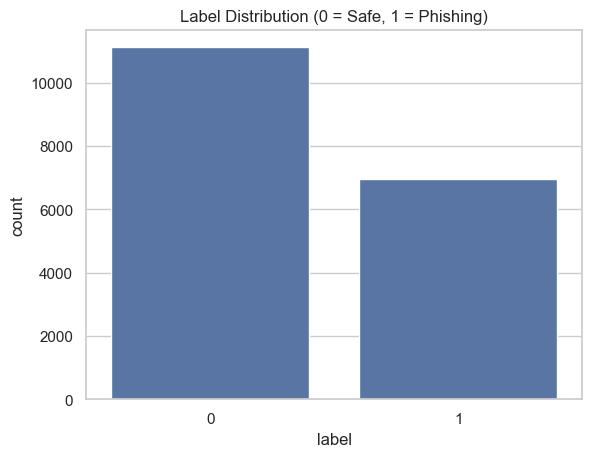

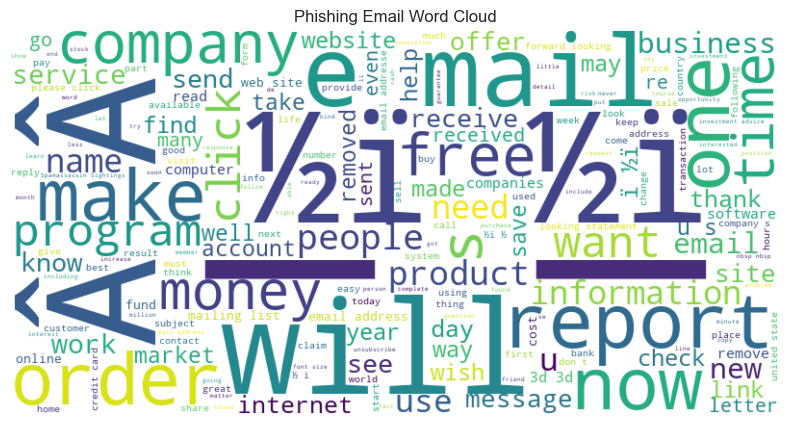

In [4]:
# Label distribution
sns.countplot(x='label', data=df)
plt.title("Label Distribution (0 = Safe, 1 = Phishing)")
plt.show()

# Word cloud
text = " ".join(df[df['label'] == 1]['text'].values)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Phishing Email Word Cloud")
plt.show()


In [ ]:

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.95,
    min_df=5,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Train shape: (14473, 89428)
Test shape: (3619, 89428)


In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Linear SVM": LinearSVC(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "confusion_matrix": cm,
        "report": report
    }

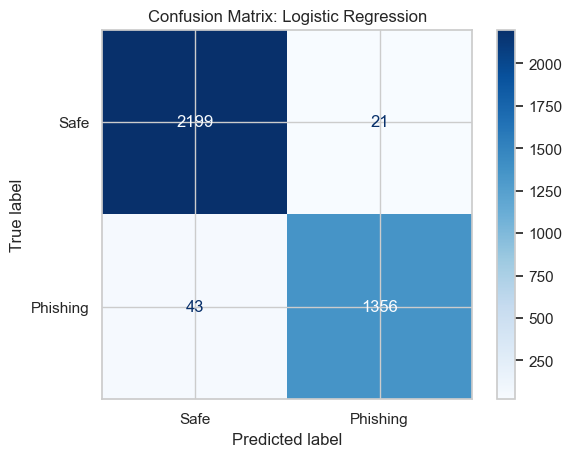

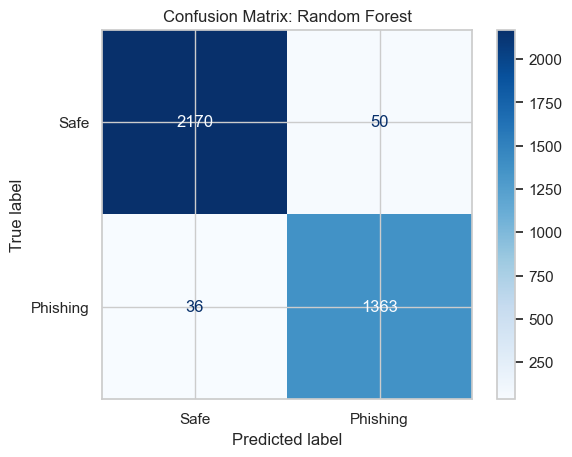

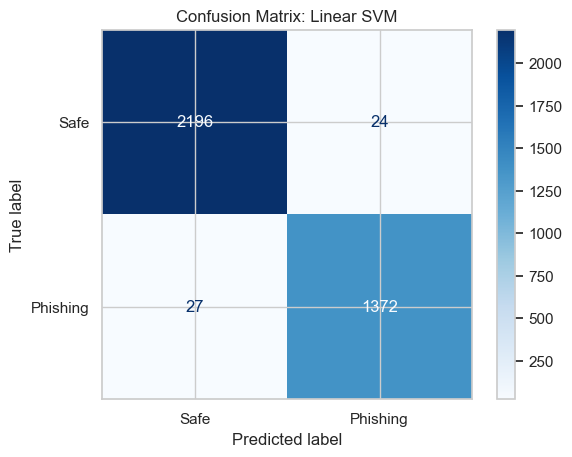

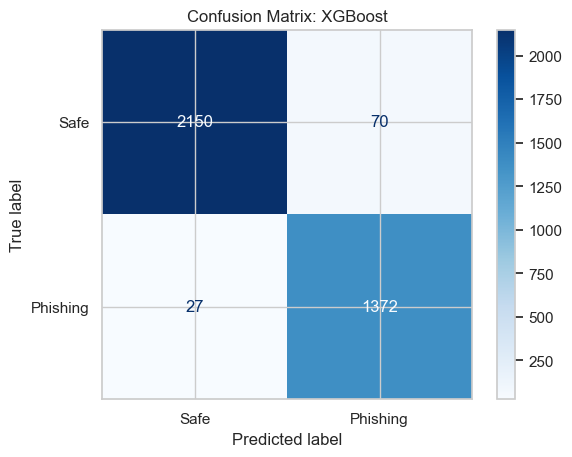

In [8]:
for name in results:
    cm = results[name]['confusion_matrix']
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Safe", "Phishing"])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

In [9]:
metrics = []

for name, res in results.items():
    report = res["report"]
    metrics.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1 Score": report["1"]["f1-score"]
    })

metrics_df = pd.DataFrame(metrics).set_index("Model").round(3)
display(metrics_df)

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.982,0.985,0.969,0.977
Random Forest,0.976,0.965,0.974,0.969
Linear SVM,0.986,0.983,0.981,0.982
XGBoost,0.973,0.951,0.981,0.966


In [10]:

best_model  = results["Logistic Regression"]  

# Save the best model and vectorizer
joblib.dump(best_model['model'], os.path.join(notebook_dir, "..", "models", "best_model.pkl"))
joblib.dump(vectorizer, os.path.join(notebook_dir, "..", "models", "vectorizer.pkl"))

['c:\\Users\\mkajd\\PhishFinder\\Backend\\app\\ml_pipeline\\notebooks\\..\\models\\vectorizer.pkl']